In [ ]:
# Imports and Setup

from glass_dynamics.core.logger import logger

from glass_dynamics.data.processor import filter_and_fit_dataset
from glass_dynamics.data.composition import gen_atomic_df
from glass_dynamics.data.splitting import split_by_cassar_indices, split_by_random_seed

from glass_dynamics.features.generator import generate_all_features, generate_cassar_35_features
from glass_dynamics.features.correlation import select_features_from_clusters
from glass_dynamics.features.vif import calculate_vif, calculate_ridge_vif, iterative_vif_selection, fast_iterative_vif_selection

from glass_dynamics.analysis.performance import compute_alpha_performance_metrics
from glass_dynamics.analysis.traces import compute_weight_traces
from glass_dynamics.analysis.feature_importance_old import extract_importance
from glass_dynamics.analysis.evolution import extract_top_features_evolution
from glass_dynamics.analysis.extrapolation import generate_extrapolation_metrics
from glass_dynamics.analysis.myega_bootstrap import generate_bootstrap_predictions

from glass_dynamics.visualization.features_exploration_plots import plot_pearson_correlation, generate_feature_metadata_table
from glass_dynamics.visualization.performance_plots import plot_target_performance
from glass_dynamics.visualization.traces_plots import plot_normalized_traces
from glass_dynamics.visualization.importance_plots import plot_sorted_feature_importance
from glass_dynamics.visualization.evolution_plots import plot_top_features_evolution
from glass_dynamics.visualization.density_plots import plot_viscosity_density_correlation
from glass_dynamics.visualization.distance_plots import plot_rmse_vs_distance_square
from glass_dynamics.visualization.viscosity_grids import plot_viscosity_grids_bootstrap

from glass_dynamics.models.ridge import CustomRidgeRegression

from glass_dynamics.evaluation.model_evaluation import evaluate_final_model

from glass_dynamics.utils.naming import generate_glass_names

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import pickle


analysis_name = "W_A_cassar"

data_path = Path(f"../../data/cassar_split/VIF/{analysis_name}")
plots_path = Path(f"../../plots/ols/{analysis_name}")
model_path = Path(f"../../models/ols/{analysis_name}")
plots_path.mkdir(parents=True, exist_ok=True)
data_path.mkdir(parents=True, exist_ok=True)
model_path.mkdir(parents=True, exist_ok=True)


In [75]:
# Data Loading
logger.info("Loading datasets...")

raw_data = pd.read_csv('../../data/viscosity_raw_data.csv', index_col=0)
chemical_props_T = pd.read_csv("../../data/chemical_properties.csv", index_col=0).T
chemical_props = pd.read_csv("../../data/chemical_properties.csv", index_col=0)

X_train = pd.read_parquet(data_path / 'X_train.parquet')
X_test = pd.read_parquet(data_path / 'X_test.parquet')

y_train = pd.read_parquet('../../data/cassar_split/y_train.parquet')
y_test = pd.read_parquet('../../data/cassar_split/y_test.parquet')

# raw_data

[INFO] 2026-09-21 20:59:38 - Loading datasets...


In [76]:
# Convert Oxides to Elements
oxides_duplicated_df = raw_data.drop(columns=['T', 'log_visc'])
oxides_df = oxides_duplicated_df.drop_duplicates().set_index('ID')

atomic_df = gen_atomic_df(oxides_df, chemical_props_T)
# atomic_df


[INFO] 2026-09-21 20:59:38 - Converting compound fractions to elemental atomic fractions using chemparse...
[INFO] 2026-09-21 20:59:38 - Successfully converted. Output shape: (847, 59)


In [77]:
# Standardize features and output
X_scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

y_scaler = StandardScaler().set_output(transform="pandas")
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

# y_test_scaled

,Type,Aggregator,Chemical Property
0,W,max,GSbandgap
1,W,max,GSvolume pa
2,W,max,NValence
3,W,max,NdUnfilled
4,W,max,NdValence
5,W,max,NsUnfilled
6,W,max,SpaceGroupNumber
7,W,max,atomic radius
8,W,max,atomic volume
9,W,max,c6 gb


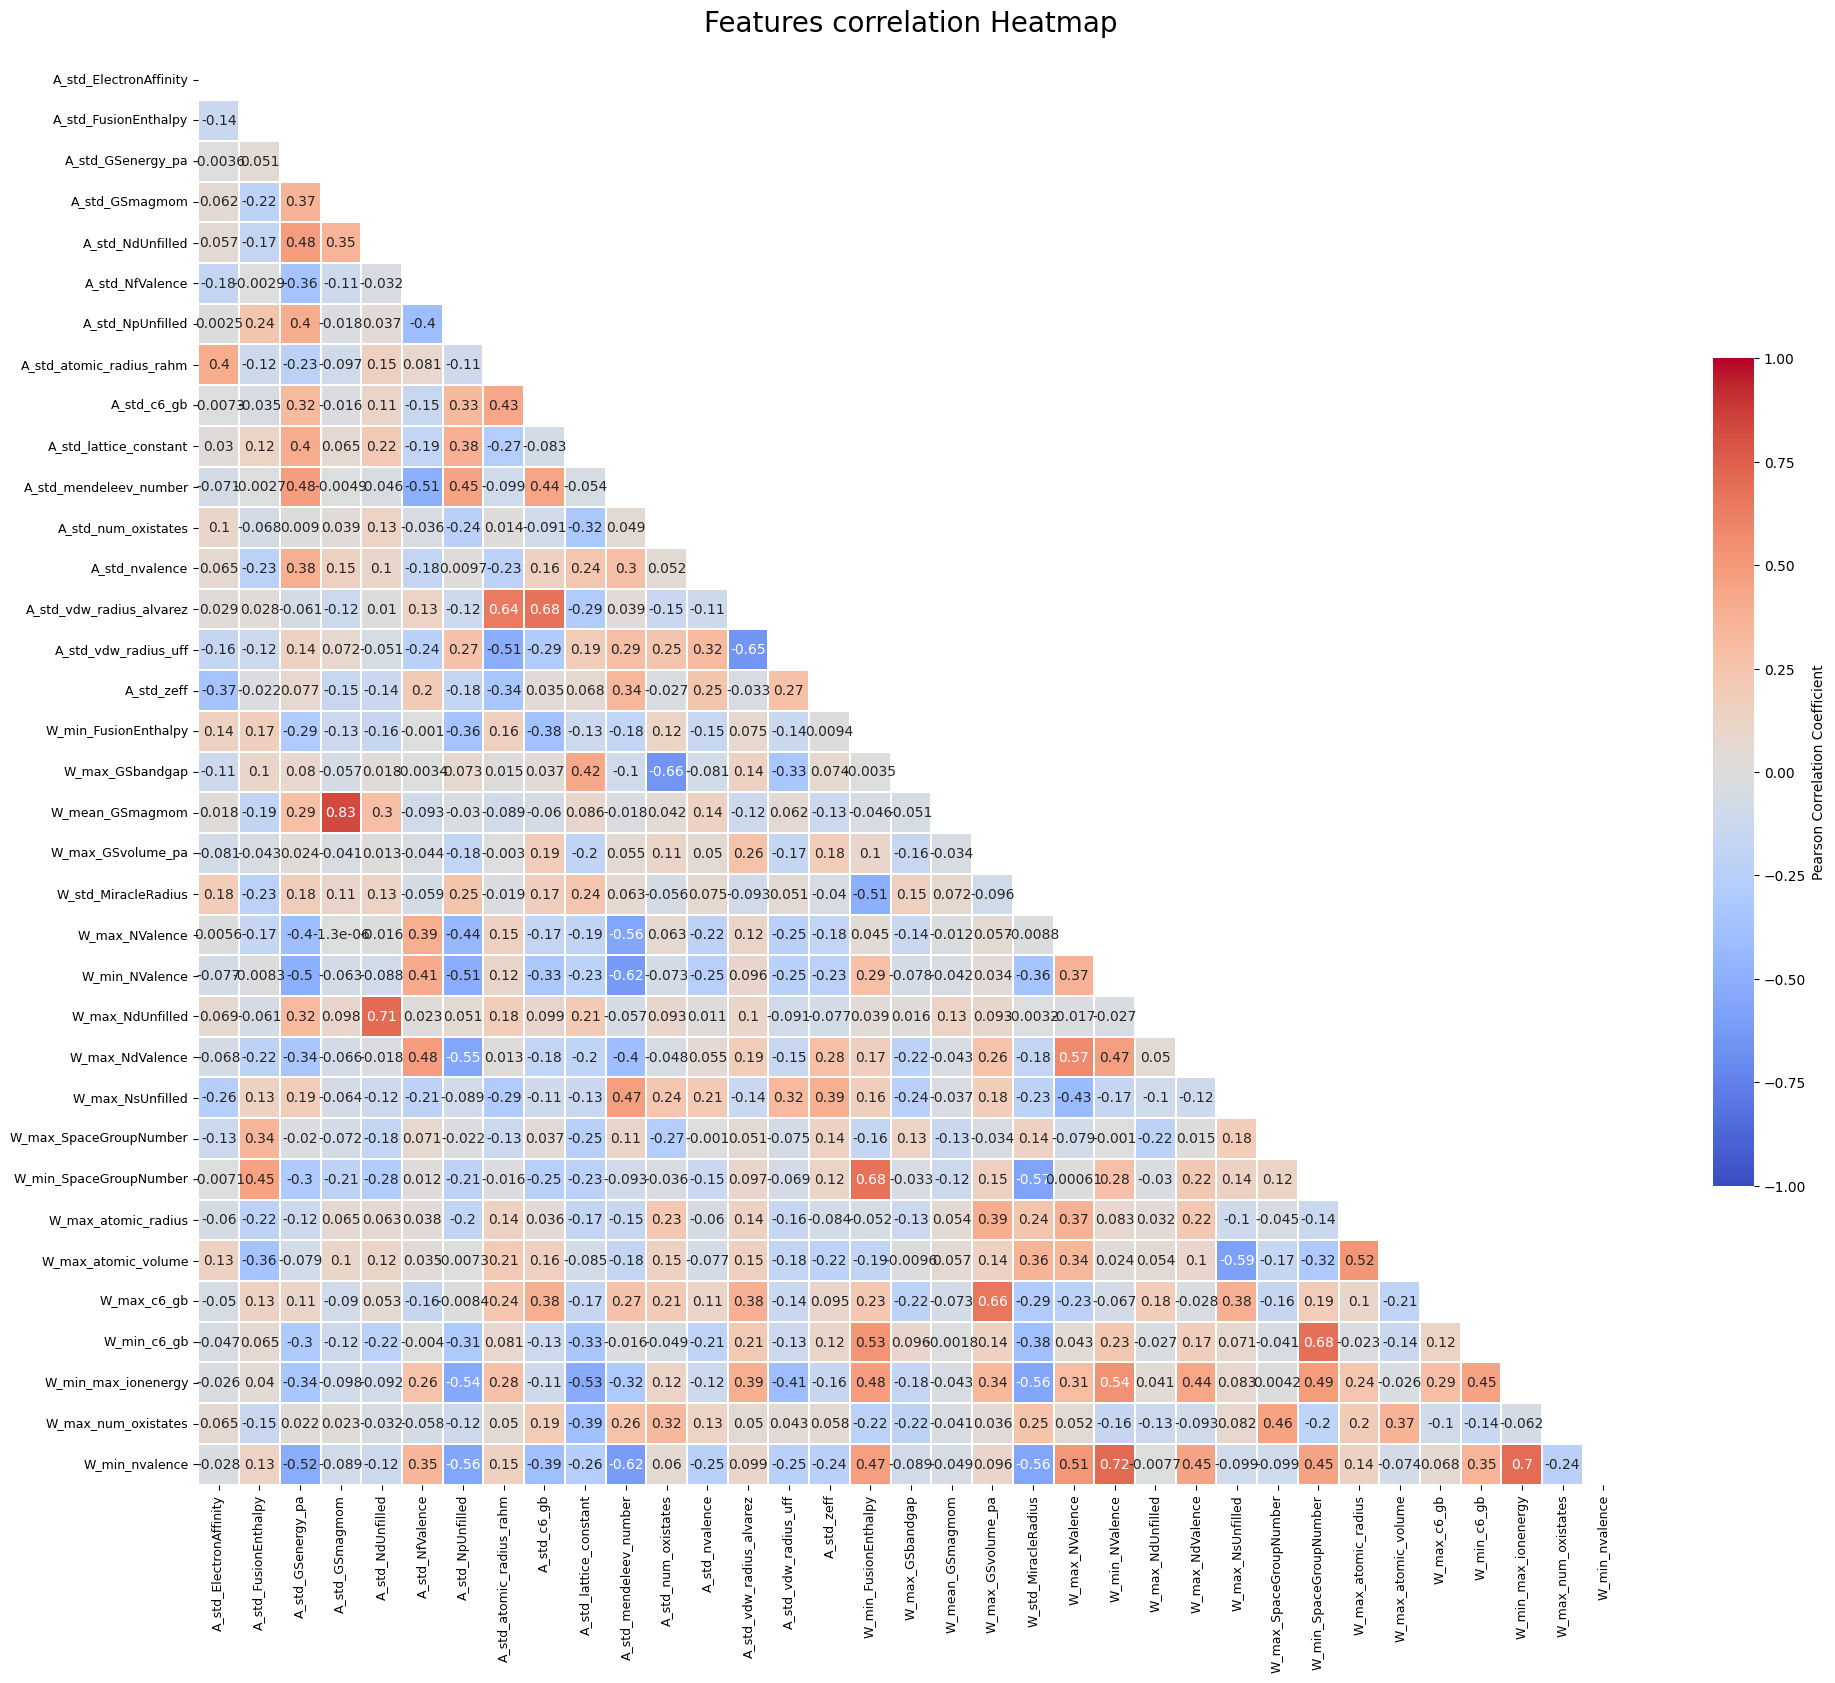

In [78]:
# Selected features visualization
corr_plot = plot_pearson_correlation(X_train_scaled, show_numbers=True)
corr_plot.savefig(plots_path / 'correlation_matrix.pdf', bbox_inches='tight')

df_features = generate_feature_metadata_table(X_train_scaled)
display(df_features[['Type', 'Aggregator', 'Chemical Property']])


In [79]:
# Compute Standard VIF
logger.info("Computing Standard OLS VIF on clustered features...")
X_standard_vif_df = calculate_vif(X_train_scaled)
print("\n--- Standard OLS VIF (Top 10 Worst Features) ---")
print(X_standard_vif_df.head(40))


# Compute Ridge VIF (alpha = 0.1) to see stabilization (Sharma et al. paper)
# logger.info("Computing Ridge VIF (alpha=0,1)...")
# ridge_vif_df = calculate_ridge_vif(X_scaled, alpha=0.1)
# print("\n--- Ridge VIF alpha=0.1 (Top 10 Worst Features) ---")
# print(ridge_vif_df.head(10))

[INFO] 2026-09-21 20:59:40 - Computing Standard OLS VIF on clustered features...
[INFO] 2026-09-21 20:59:40 - Calculating standard OLS VIF for features...

--- Standard OLS VIF (Top 10 Worst Features) ---
                     Feature       VIF
0                A_std_c6_gb  8.205313
1   A_std_vdw_radius_alvarez  6.696218
2             W_min_nvalence  6.309251
3     A_std_mendeleev_number  6.244464
4           A_std_NpUnfilled  6.232420
5     W_min_SpaceGroupNumber  6.084738
6            W_max_NdValence  5.888209
7                 A_std_zeff  5.842052
8        W_min_max_ionenergy  5.583249
9           W_max_NsUnfilled  5.360924
10    A_std_lattice_constant  5.252611
11       A_std_num_oxistates  5.156910
12               W_max_c6_gb  5.135861
13           W_max_GSbandgap  5.063746
14       W_max_atomic_volume  4.862410
15  A_std_atomic_radius_rahm  4.688228
16    W_max_SpaceGroupNumber  4.573910
17      A_std_vdw_radius_uff  4.468447
18      A_std_FusionEnthalpy  4.421216
19            A

[INFO] 2026-09-21 20:59:40 - Extracting raw feature importance at alpha=0.0 over 100 splits.
[INFO] 2026-09-21 20:59:40 - Rendering sorted raw feature importance S-curves for 3 targets.


,feature,original_index,weight,std,abs_weight
0,W_max_GSbandgap,17,-0.581685,0.051304,0.581685
1,W_max_NsUnfilled,25,-0.435398,0.052477,0.435398
2,W_max_NdValence,24,-0.361139,0.045224,0.361139
3,A_std_NpUnfilled,6,0.258639,0.052956,0.258639
4,W_max_atomic_volume,29,0.248534,0.059712,0.248534
5,W_max_SpaceGroupNumber,26,0.191901,0.038064,0.191901
6,W_max_num_oxistates,33,-0.188497,0.041934,0.188497
7,W_min_NValence,22,-0.172473,0.033791,0.172473
8,W_std_MiracleRadius,20,-0.169283,0.037151,0.169283
9,W_max_NValence,21,-0.160188,0.038396,0.160188


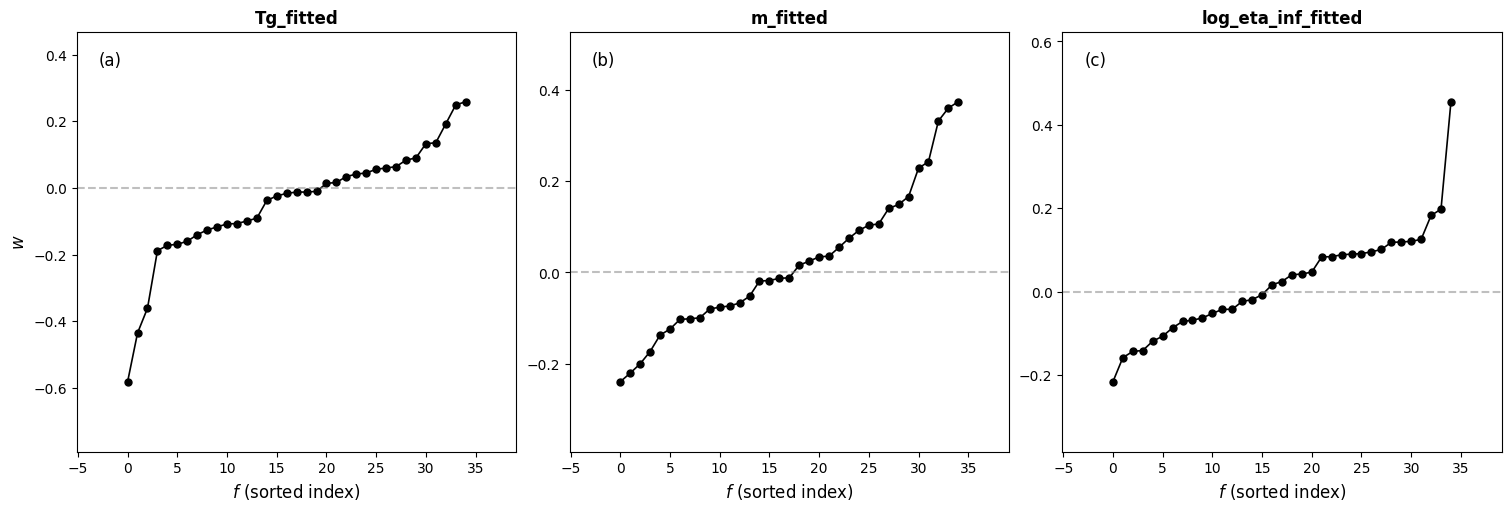

In [80]:
# Feature weights plots (ordered)
importance_data = extract_importance(
    X=X_train_scaled,
    y=y_train_scaled,
    alpha=0.0,
    n_splits=100,
    sort_by='magnitude' # <- Ordina per il peso più forte, a prescindere dal segno
)

fig_importance = plot_sorted_feature_importance(importance_data, top_n=0)
fig_importance.savefig(plots_path / 'features_importance.pdf', bbox_inches='tight')


importance_data['Tg_fitted'].head(10)
# print("\nTop 10 features per Tg_fitted:")
# print(importance_data['Tg_fitted'].head(10)[['original_index', 'feature', 'weight', 'abs_weight']])

In [81]:
# Training model

# Instantiate the model with alpha = 0.0
ols_model = CustomRidgeRegression(alpha=0.0, fit_intercept=True)

# Fit the model on the training data
ols_model.fit(X_train_scaled, y_train_scaled)

pickle.dump(ols_model, open(model_path / "ols_model.pkl", 'wb'))

logger.info("Model successfully trained and saved!")

[INFO] 2026-09-21 20:59:41 - Model successfully trained and saved!


In [82]:
# Evaluating model

target_columns = ['Tg', 'm','log_eta_inf']

evaluation_metrics = evaluate_final_model(
    model=ols_model,
    X_test=X_test_scaled,
    y_test=y_test_scaled,
    viscosity_df=raw_data,
    target_cols=target_columns,
    y_scaler=y_scaler
)

[INFO] 2026-09-21 20:59:41 - Evaluating model on the unseen Test Set (85 glasses)...

      TEST SET PERFORMANCE (SCALED PARAMETERS)
Target: Tg
  Pearson : 0.883
  R^2     : 0.779
  RMSE    : 0.444
  MAE     : 0.337
  MedAE   : 0.277
--------------------------------------------------
Target: m
  Pearson : 0.835
  R^2     : 0.694
  RMSE    : 0.569
  MAE     : 0.453
  MedAE   : 0.395
--------------------------------------------------
Target: log_eta_inf
  Pearson : 0.424
  R^2     : 0.175
  RMSE    : 0.844
  MAE     : 0.607
  MedAE   : 0.408
--------------------------------------------------
[INFO] 2026-09-21 20:59:41 - Computing global viscosity performance via MYEGA equation...

      VISCOSITY: PREDICTED vs TRUE FITTED (MYEGA)
--------------------------------------------------
  Pearson : 0.911
  R^2     : 0.753
  RMSE    : 2.012
  MAE     : 1.310
  MedAE   : 0.885
      VISCOSITY: PREDICTED vs EXPERIMENTAL (GROUND TRUTH)
--------------------------------------------------
  Pearson : 

[INFO] 2026-09-21 20:59:42 - Rendering 2D density correlation plot with residual inset.


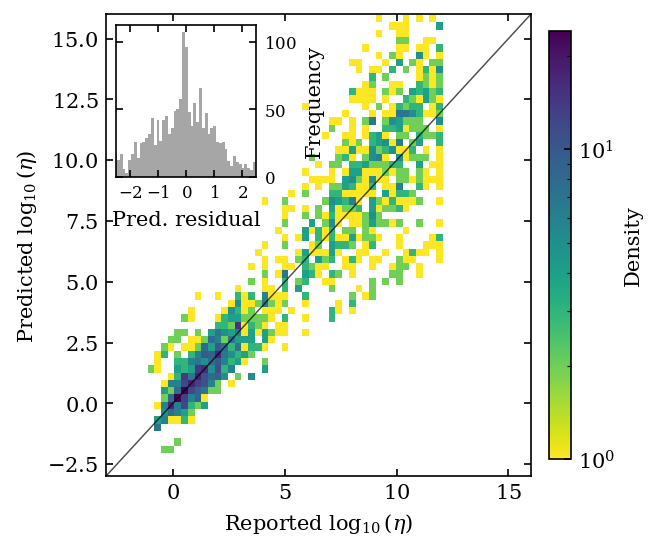

In [83]:
# Cassar density plot

y_true_visc = evaluation_metrics["viscosity_arrays"]["true_experimental"]
y_pred_visc = evaluation_metrics["viscosity_arrays"]["predicted_myega"]

fig_density = plot_viscosity_density_correlation(
    y_true=y_true_visc, 
    y_pred=y_pred_visc
)

fig_density.savefig(plots_path / '2D_density_histogram.pdf', bbox_inches='tight')
fig_density.savefig(plots_path / '2D_density_histogram.png', bbox_inches='tight')

[INFO] 2026-09-21 20:59:43 - Extracting distance and RMSE metrics into a DataFrame.


,ID,Name,Distance,RMSE
0,846,25Li₂O.25Na₂O.50P₂O₅,1.321678,10.893393
1,428,15Na₂O.27PbO.58SiO₂,0.095810,4.001869
2,141,50B₂O₃.50ZnO,2.000000,3.967212
3,293,20BeO.60GeO₂.20Na₂O,0.410256,3.828835
4,123,50BaO.50P₂O₅,0.306905,3.663565
5,26,9Al₂O₃.6B₂O₃.1BaO.12K₂O.19MgO.53P₂O₅,3.864145,3.482237
6,659,54B₂O₃.21Na₂O.25SiO₂,0.428105,3.477465
7,51,3Al₂O₃.10B₂O₃.25BaO.6CaO.52SiO₂.5ZnO,1.658671,3.362763
8,233,7Al₂O₃.11BeO.3K₂O.4Na₂O.76SiO₂,1.227778,3.194664
9,201,50Na₂O.50P₂O₅,0.100251,3.185441


[INFO] 2026-09-21 20:59:43 - Rendering square scatter plot for Extrapolation Distance vs RMSE.


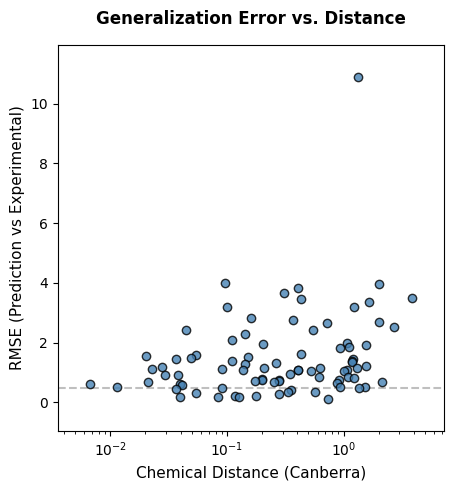

In [84]:
# Test glasses vs performance analysis

# Get glass names
compounds = raw_data.columns[:-3].tolist()
glass_names_dict = generate_glass_names(raw_data, compounds)

# Get model prediction
y_pred_scaled  = ols_model.predict(X_test_scaled)
y_pred_physical = y_scaler.inverse_transform(y_pred_scaled)

target_columns = ['Tg', 'm','log_inf']

# Prediction dataframe
predictions_df = pd.DataFrame(
    y_pred_physical,
    columns=target_columns,
    index=y_test.index
)

# Generating distance data
metrics_df = generate_extrapolation_metrics(
    compounds=compounds,
    viscosity_df=raw_data,
    predictions_df=predictions_df, 
    names_dict=glass_names_dict
)
display(metrics_df.head(10))

# Generating distance plot
fig_distance = plot_rmse_vs_distance_square(metrics_df)
fig_distance.savefig(plots_path / 'distance_plot.pdf', bbox_inches='tight')

[INFO] 2026-09-21 20:59:44 - Training ensemble of 100 bootstrap models...
[INFO] 2026-09-21 20:59:44 - Rendering bootstrap prediction grids for 85 glasses.


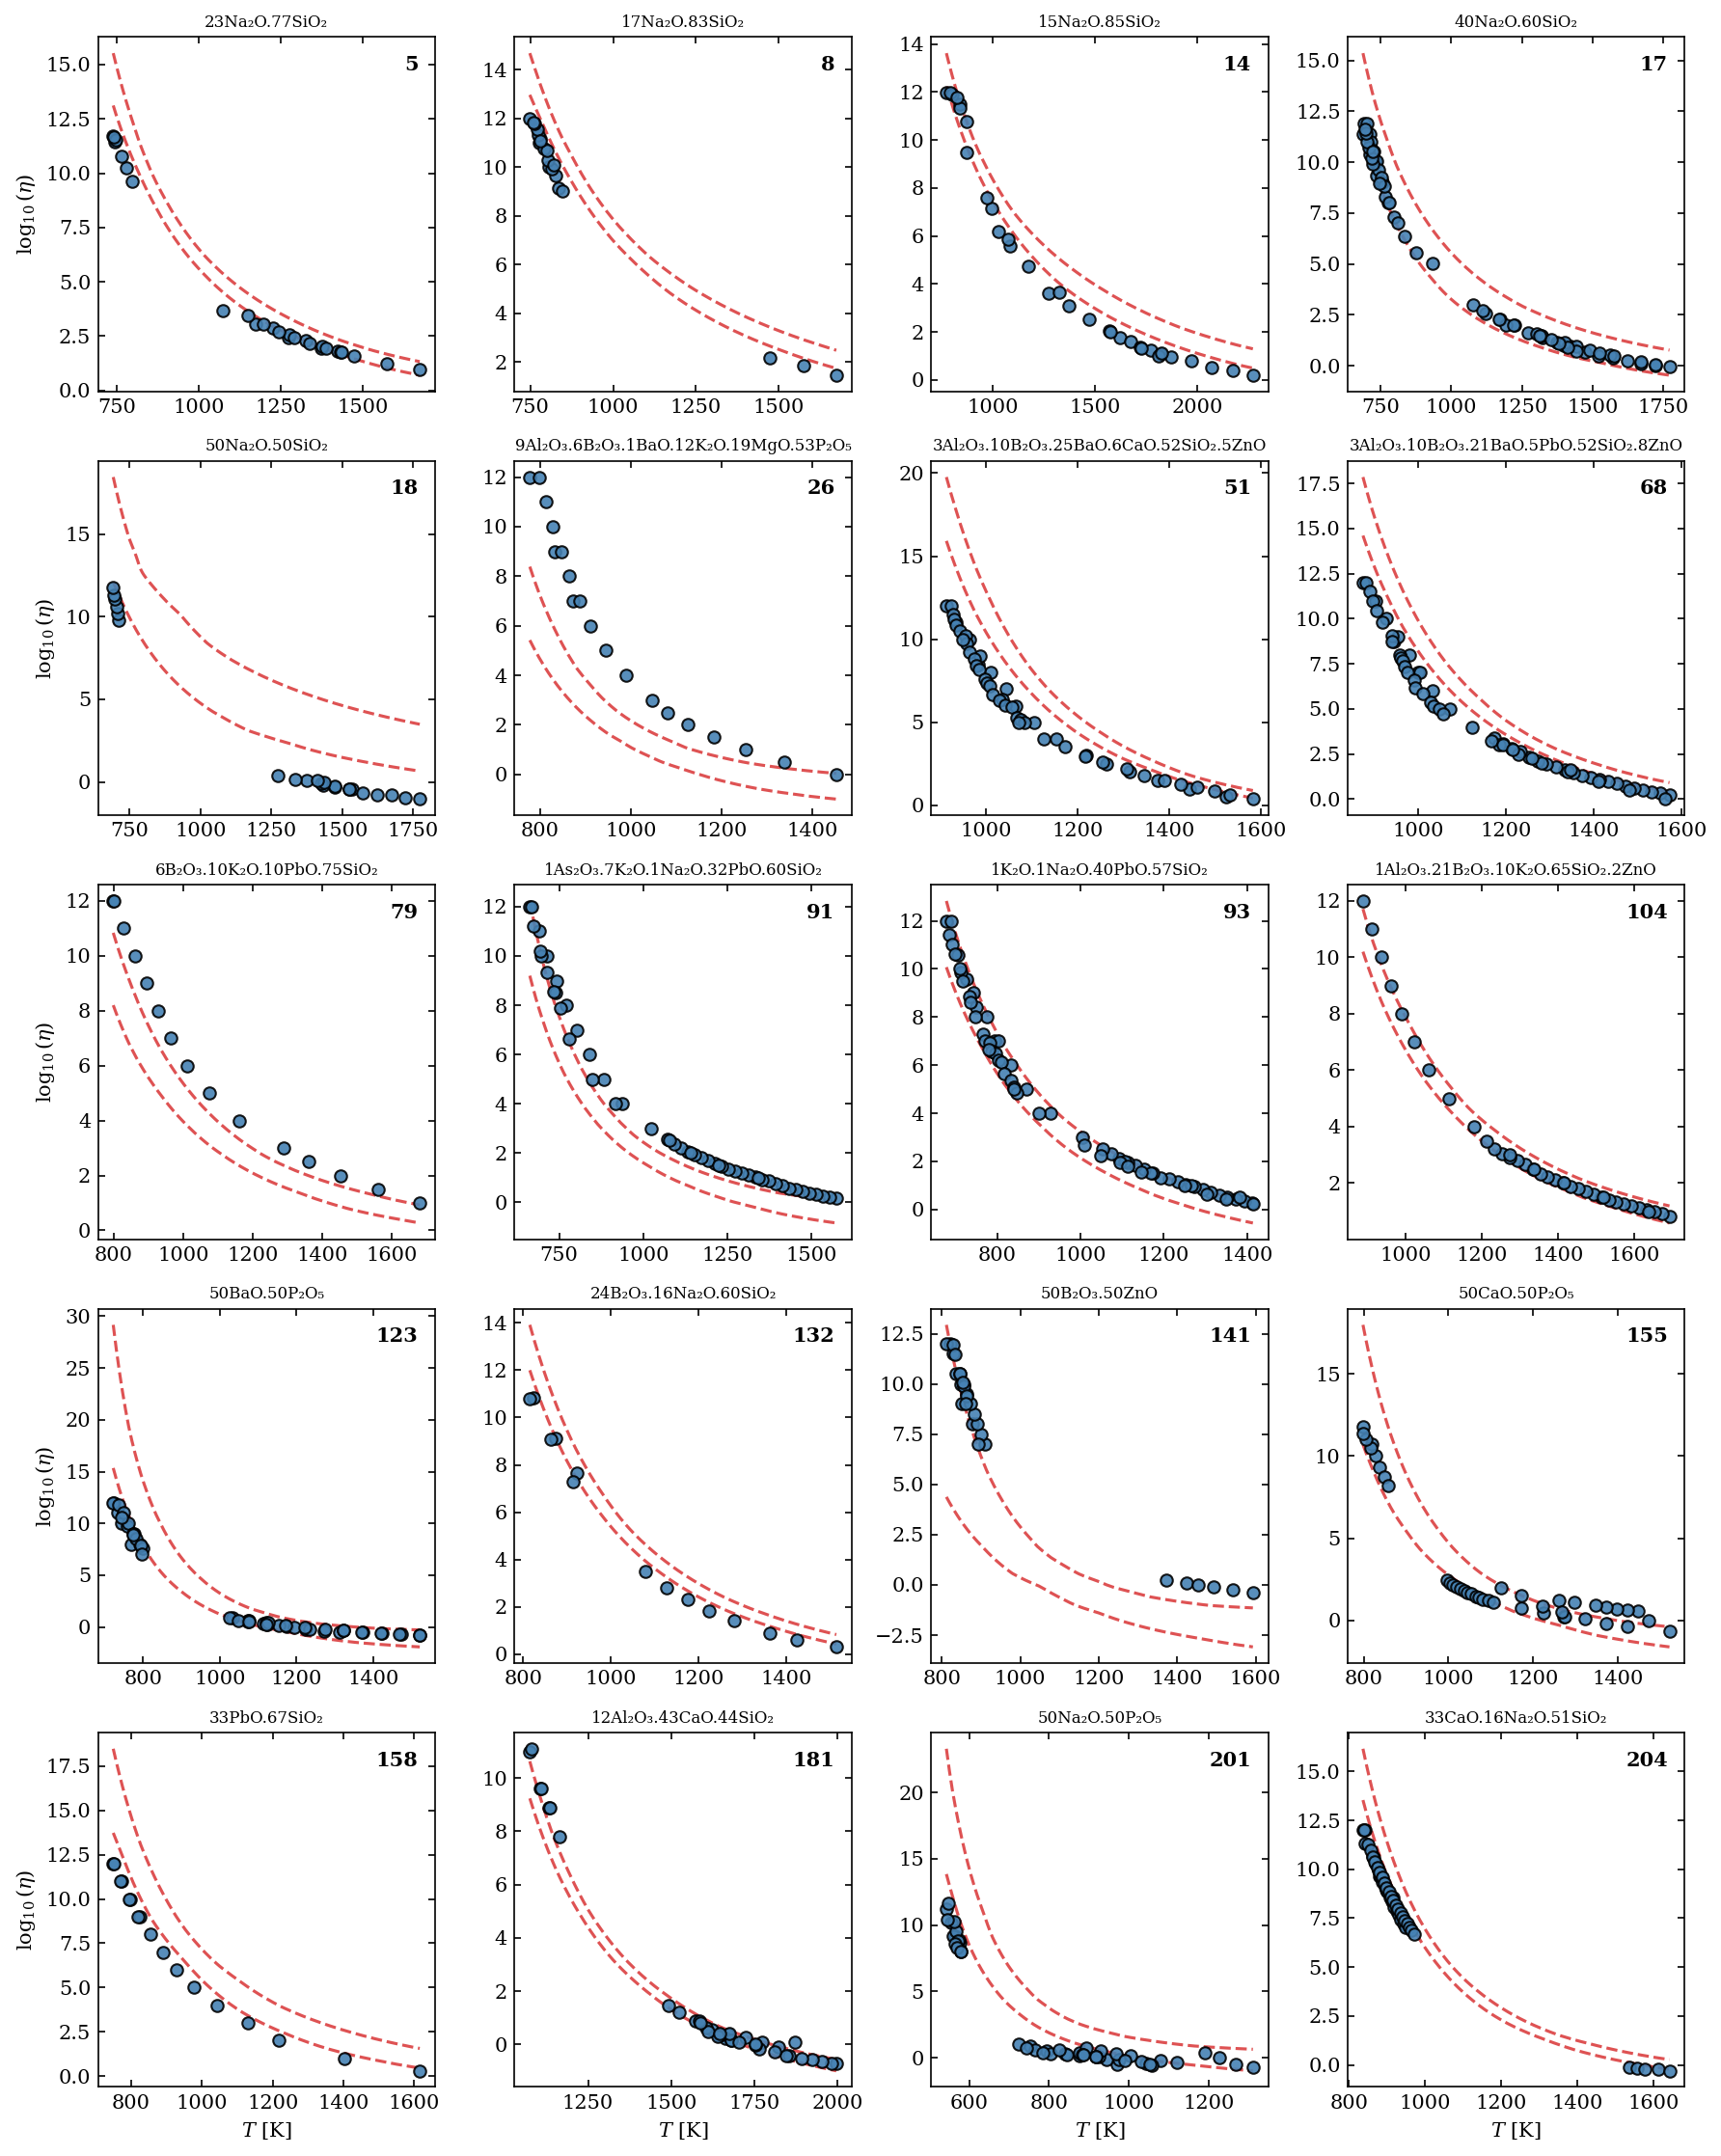

In [85]:
# Plotting test liquids viscosities with uncertainty bars

base_ols = CustomRidgeRegression(alpha=0.0, fit_intercept=True)

predictions_df, distributions_dict = generate_bootstrap_predictions(
    base_model=base_ols,
    X_train=X_train_scaled,
    y_train=y_train_scaled,
    X_test=X_test_scaled,
    y_scaler=y_scaler,
    n_estimators=100
)

viscosity_plots_path = plots_path / "test_viscosity_plots"
viscosity_plots_path.mkdir(parents=True, exist_ok=True)

plot_viscosity_grids_bootstrap(
    viscosity_df=raw_data,
    distributions_dict=distributions_dict,
    names_dict=glass_names_dict,
    save_dir=viscosity_plots_path,
    confidence=95.0
)